# Build vanilla RNN from scratch

Building a Long Short-Term Memory network from the ground up — the gates, the cell state, the backprop — then training it on daily gold prices.

In [404]:
import csv
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

### Import the price data of GOLD

In [405]:
with open('gold.csv') as f:
    rows = list(csv.DictReader(f))
print(rows[:3])
prices = torch.tensor([float(row['Close']) for row in rows], dtype=torch.float32)
dates = [row['Date'] for row in rows]
print(len(prices), " trading days!")
print(prices[:3])
print(dates[:3])

[{'Date': '2021-07-20', 'Close': '1810.9'}, {'Date': '2021-07-21', 'Close': '1802.9'}, {'Date': '2021-07-22', 'Close': '1805.0'}]
1257  trading days!
tensor([1810.9000, 1802.9000, 1805.0000])
['2021-07-20', '2021-07-21', '2021-07-22']


### Normalize price and create train/test split

In [406]:
# Daily log returns of prices
rets = torch.log(prices[1:]) - torch.log(prices[:-1])

# Normalize using mean and std after making the training/validation split
n = int(0.5 * len(prices)) # find the 90% mark of the dataset

mean, std = rets[:n].mean(), rets[:n].std()
data = (rets - mean) / std

train_data = data[:n]
val_data = data[n:]

print(f'{len(train_data)} train days, {len(val_data)} val days')
print(f'train mean {mean.item():.6f}, train std {std.item():.6f}')
print('train_data[:5]: ', train_data[:5])
print('val_data[:5]: ', val_data[:5])

628 train days, 628 val days
train mean 0.000173, train std 0.008978
train_data[:5]:  tensor([-0.5124,  0.1104, -0.2416, -0.1863,  0.0302])
val_data[:5]:  tensor([ 0.4158, -0.3881,  0.1956, -0.5599,  0.1465])


Text(0.5, 1.0, 'gold price (USD)')

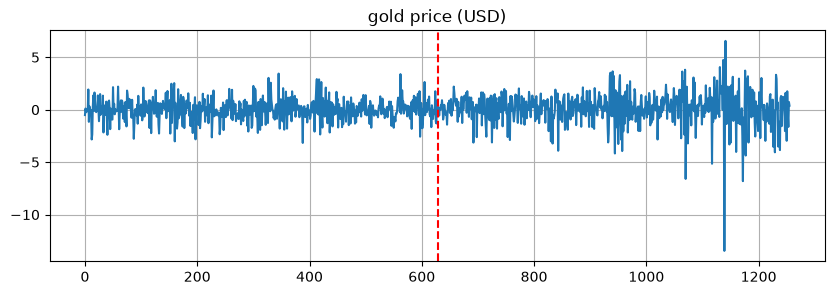

In [407]:
plt.figure(figsize=(10, 3))
plt.plot(data) # swap 'data' with 'prices' to see the actual price
plt.axvline(len(train_data), color='r', linestyle='--')
plt.grid()
plt.title("gold price (USD)")

### **get_batch(split, batch_size, block_size)**: returns a single batch of multiple windows and their targets

In [408]:
# block_size = 64 # OR Context Length; How many days of history does the model get to see?
# batch_size = 32 # How many independent windows will bwe process in parallel?

# print(f"Number of possible batches: {len(train_data) - block_size}")

def get_batch(split, batch_size=32, block_size=64):
    # Sample a batch(batch_size) of sequences(block_size) each batch example starting from a random index in ix
    data =  train_data if split == 'train' else val_data
    ix = torch.randint(low=0, high=len(data)-block_size-1, size=(batch_size,)) # starting index for each batch(batch_size: total no. of batches)
    x = torch.stack([data[i : i+block_size] for i in ix]).unsqueeze(-1) # torch.stack bundles these 32 snippets into a single 3D block (Tensor).
    y = torch.stack([data[i+1 : i+block_size+1] for i in ix]).unsqueeze(-1) # unsqueeze(-1) adds a final dimension to indicate that each day contains just 1 number (the price return),
    # print(f'Starting index of {batch_size} sequences: \n{ix}')
    # print('Sample input example x[1]:\n', x[1].squeeze(-1))  # (B=1, T)
    # print('Sample output example y[1]:\n', y[1].squeeze(-1)) # (B=1, T)
    return x, y # x.shape: (B, T, 1)

xb, yb = get_batch('train')
# print('inputs:', xb.shape)  # (B, T, C) = (batch, time, channels)
# print('targets:', yb.shape) # shifted one day into the future
# note C=1: each timestep is a single scalar. there is no embedding table here -
# our "tokens" are continuous numbers, so the recurrence itself has to do all the work

### Baseline to beat (the "do nothing" forecaster)

In [409]:
# a baseline to beat: the "do nothing" forecaster, which always predicts 0 (= no change tomorrow)
# any model that can't beat this is useless
eval_iters = 50
baseline={}
for split in ['train', 'val']:
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        X, Y = get_batch(split)
        losses[k] = (Y**2).mean()
    baseline[split] = losses.mean()
    print(f'do-nothing baseline {split} loss: {losses.mean():.4f}')

do-nothing baseline train loss: 0.9912
do-nothing baseline val loss: 2.4876


## **RNN** architecture

### The mathematical trick in recurrence: the hidden state

Before the LSTM, let's build the thing it fixed. A vanilla RNN keeps a hidden state `h` that gets overwritten every timestep by squashing the past and the present through a `tanh`:

`h_t = tanh(Wx @ x_t + Wh @ h_{t-1} + b)`

In [410]:
# version 1: an explicit loop over time, with raw tensors. consider the following toy example
torch.manual_seed(1337)
B, T, C, H = 1, 5, 1, 3

Wx = torch.randn(1, H) * 0.1  # input -> hidden
Wh = torch.randn(H, H) * 0.1  # hidden -> hidden
b = torch.zeros(H)

h = torch.zeros(B, H)             # the hidden state starts at zero
x = torch.randn(B, T, C)          # a toy sequence of 5 scalars
for t in range(T):
    h = torch.tanh(x[:, t, :] @ Wx + h @ Wh + b) # (B,1)@(1,H) + (B,H)@(H,H) -> (B,H)
    print(f't={t}: h = {[round(v, 3) for v in h[0].tolist()]}')
# h is the entire memory of the network - a single vector, re-written every step

t=0: h = [-0.127, -0.129, -0.076]
t=1: h = [-0.1, -0.108, -0.084]
t=2: h = [0.02, 0.013, -0.009]
t=3: h = [0.034, 0.033, 0.023]
t=4: h = [0.238, 0.245, 0.15]


In [411]:
class RNNCell:
    """ a single vanilla RNN timestep: h_t = tanh(Wx x_t + Wh h_{t-1} + b) """
    def __init__(self, input_size, hidden_size, generator=None):
        gain = 5 / 3  # tanh gain
        std_x = gain / (input_size ** 0.5)  # The 5/3 factor specifically compensates for tanh's compression near saturation, 
        std_h = gain / (hidden_size ** 0.5) # so the output variance stays ≈1 layer after layer instead of shrinking.

        self.Wx = (torch.randn(input_size, hidden_size, generator=generator) * std_x).requires_grad_()
        self.Wh = (torch.randn(hidden_size, hidden_size, generator=generator) * std_h).requires_grad_()
        self.b  = torch.zeros(hidden_size).requires_grad_()

    def __call__(self, x, h):
        out = torch.tanh(x @ self.Wx + h @ self.Wh + self.b)
        return out

    def parameters(self):
        return [self.Wx, self.Wh, self.b]

In [412]:
class RNN:
    """ a vanilla RNN unrolled over a sequence """
    def __init__(self, input_size, hidden_size, generator=None):
        self.cell = RNNCell(input_size, hidden_size, generator=generator)
        self.hidden_size = hidden_size

    def __call__(self, x, hx=None):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, dtype=x.dtype) if hx is None else hx
        outs = []
        for t in range(T):
            h = self.cell(x[:, t, :], h)      # Unroll a RNN cell of shape (B, H) for each timestep
            outs.append(h)                    # outs is a list of T units of (B, H)
        return torch.stack(outs, dim=1), h    # Stacking all (T units) column-wise results in tensor of shape (B, T, H)
    
    def parameters(self):
        return self.cell.parameters()

In [417]:
# --- manual output head ---
g = torch.Generator().manual_seed(42)
input_size, H = 1, 16

rnn = RNN(input_size, H, generator=g)
# nn.RNN (and our RNN implementation) only compute hidden states — 
# it has no built-in projection to a task-specific output. 
# Its outputs are exactly (output, h_n):
# To get a price prediction, you always add your own output layer afterward, e.g.:
W_out = (torch.randn(H, 1, generator=g) * (1 / H**0.5)).requires_grad_()
b_out = torch.zeros(1).requires_grad_()

parameters = rnn.parameters() + [W_out, b_out]
print("total trainable tensors:", len(parameters))

total trainable tensors: 5


In [418]:
@torch.no_grad()
def estimate_loss_rnn(split, eval_iters=200):
    losses = torch.zeros(eval_iters)
    for i in range(eval_iters):
        xb, yb = get_batch(split)
        rnn_out, h_final = rnn(xb)
        # pred = rnn_out @ W_out + b_out
        pred = h_final @ W_out + b_out
        loss = ((pred - yb[:, -1, :]) ** 2).mean()
        losses[i] = loss.item()
    return losses.mean().item()

print('training loss:', estimate_loss_rnn('train'))
print('validation loss:', estimate_loss_rnn('val'))

training loss: 1.6584619283676147
validation loss: 3.6445446014404297


In [419]:
# --- training loop using torch.optim.SGD ---

# create a pytorch optimizer
optimizer = torch.optim.SGD(parameters, lr=0.001)

max_steps = 10000
lossi = []
loss_val_i = []

for i in range(max_steps):
    # mini-batch construct 
    xb, yb = get_batch('train')                # xb: (B,T,1)  yb: (B,T,1)

    # forward pass
    rnn_out, h_final = rnn(xb)                 # rnn_out: (B,T,H)
    # pred = rnn_out @ W_out + b_out             # (B,T,1) — a prediction at every timestep
    pred = h_final @ W_out + b_out             # (B,1,1) — a prediction at the last timestep
    loss = ((pred - yb[:, -1, :]) ** 2).mean()           # MSE over all B*T predictions

    # backward pass
    optimizer.zero_grad()                      # reset all parameter gradients to None
    
    # manual reset of parameters or zero_grad()
    # for p in parameters:
    #     p.grad = None
    
    loss.backward()                            # backprop to get new gradients of all params

    # update
    optimizer.step()                           # update step
    
    # manual update step of SGD
    # lr = 0.001
    # for p in parameters:
    #     p.data += -lr * p.grad

    # track stats
    if i % 1000 == 0:
        val_loss = estimate_loss_rnn('val')
        loss_val_i.append(val_loss)
        print(f'step{i:7d}/{max_steps:7d}: train loss: {loss:.4f}, val loss: {val_loss:.4f}')
    lossi.append(loss.item())

step      0/  10000: train loss: 1.5317, val loss: 3.6097
step   1000/  10000: train loss: 0.3561, val loss: 2.8233
step   2000/  10000: train loss: 0.9049, val loss: 2.5260
step   3000/  10000: train loss: 1.3002, val loss: 2.7121
step   4000/  10000: train loss: 1.0658, val loss: 2.7437
step   5000/  10000: train loss: 0.7130, val loss: 2.7005
step   6000/  10000: train loss: 1.4129, val loss: 2.7291
step   7000/  10000: train loss: 1.1135, val loss: 2.6408
step   8000/  10000: train loss: 1.1700, val loss: 2.8712
step   9000/  10000: train loss: 0.6920, val loss: 2.6656


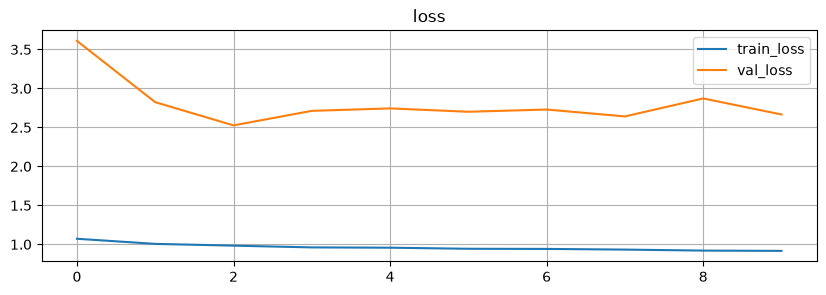

In [420]:
meanloss = torch.tensor(lossi).view(-1, 1000).mean(1, keepdim=True);
meanloss_val = torch.tensor(loss_val_i).view(-1, 1).mean(1, keepdim=True);

plt.figure(figsize=(10, 3))
plt.plot(meanloss, label='train_loss')
plt.plot(meanloss_val, label='val_loss')
plt.grid(); plt.legend(); plt.title('loss');

## **Introduction to LSTM**

### The mathematical trick in the LSTM: the cell state

The LSTM (Hochreiter & Schmidhuber, 1997) gives the network a second state `c` - the **cell state** - that is updated by *addition*, not by repeated squashing:

`c_t = f * c_{t-1} + i * g`

Because the derivative of a sum does not multiply anything together, the gradient can flow backwards through time along `c` without decaying - an additive "gradient highway". What gets written into, kept in, and read out of the highway is controlled by three **gates** - vectors of soft, differentiable if-statements in (0, 1):

- `f` (forget gate): how much of the old memory to keep
- `i` (input gate): how much of the new candidate `g` to write
- `o` (output gate): how much of the memory to expose as the hidden state `h_t = o * tanh(c_t)`

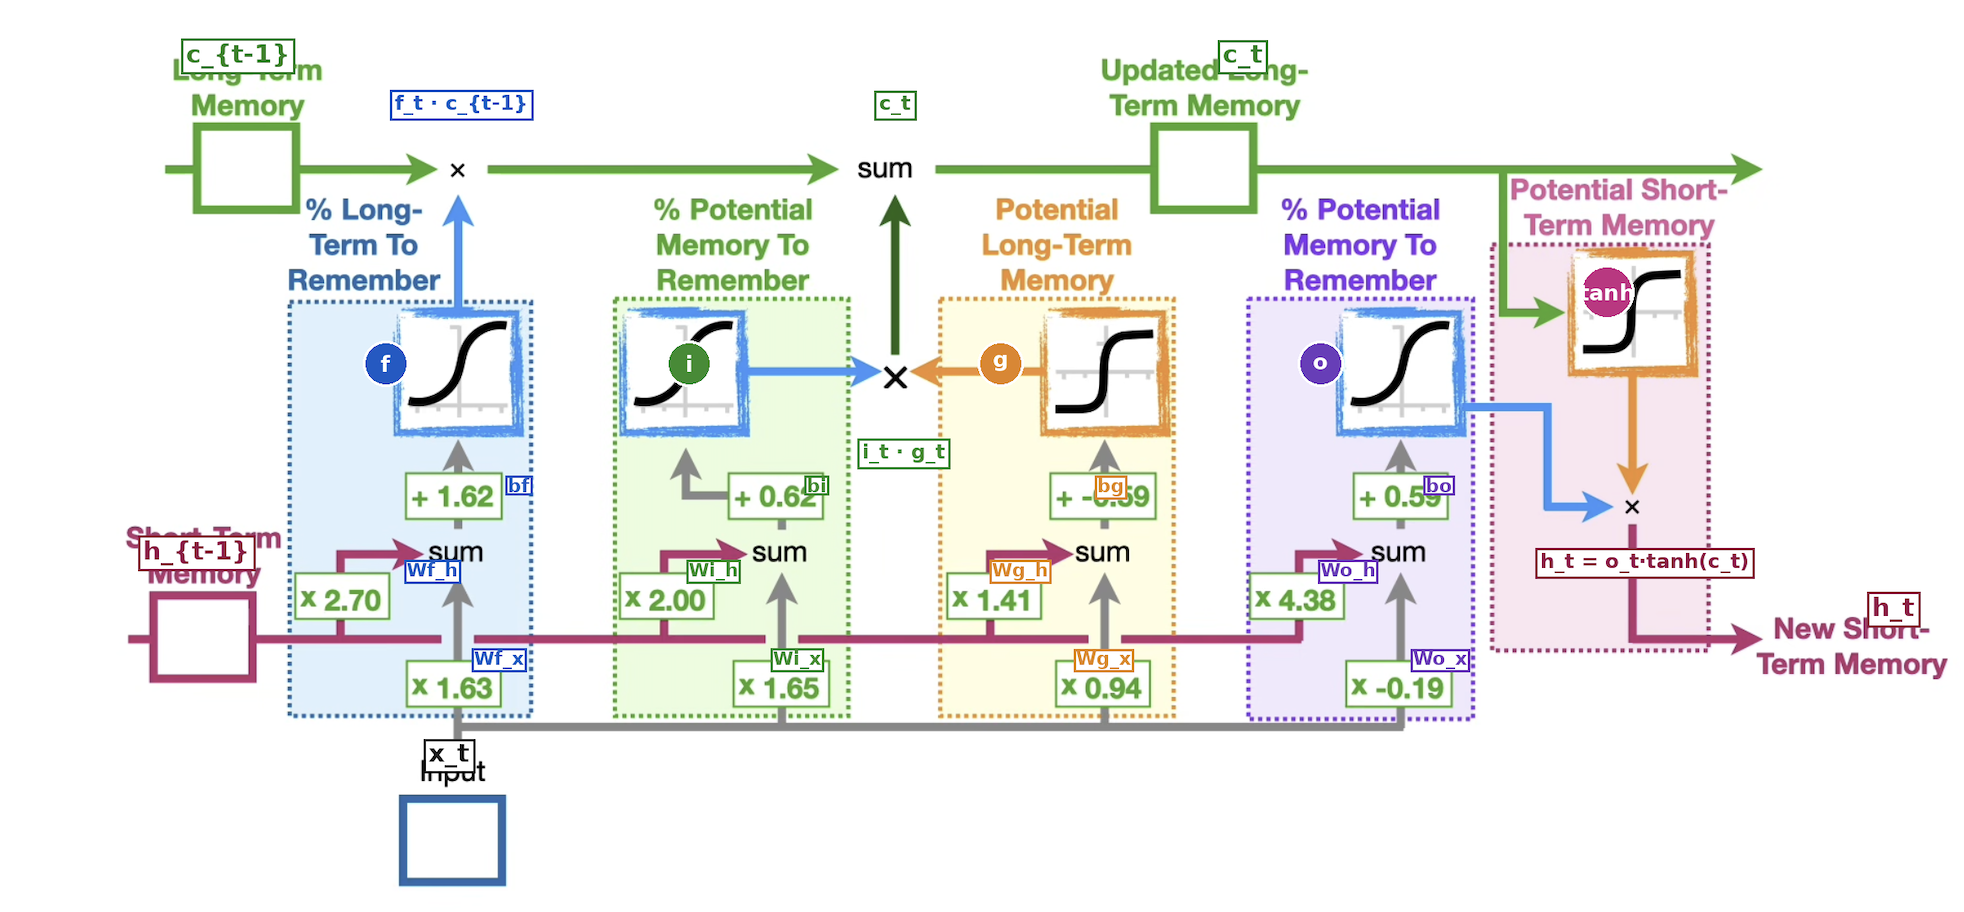

In [239]:
from IPython.display import Image, display
display(Image(filename="assets/lstm_annotated.png"))

In a single LSTM timestep, given x_t and the previous (h_{t-1}, c_{t-1}), it computes four gates and uses them to update the cell state and hidden state:

$ \qquad\qquad\mathbf{f_t} = sigmoid(W_{fx}x_t + W_{fh}h_{t-1} + bf) \;\;\;\mathbf{\#\,forget\,gate}$  
$ \qquad\qquad\mathbf{i_t} = sigmoid(W_{ix}x_t + W_{ih}h_{t-1} + bi) \;\;\;\mathbf{\#\,input\,gate}$  
$ \qquad\qquad\mathbf{g_t} = tanh(W_{gx}x_t + W_{gh}h_{t-1} + bg)    \;\;\;\mathbf{\#\,candidate\,cell\,content}$  
$ \qquad\qquad\mathbf{o_t} = sigmoid(W_{ox}x_t + W_{oh}h_{t-1} + bo) \;\;\;\mathbf{\#\,output\,gate}$  
$ \qquad\qquad\mathbf{c_t} = f_t * c_{t-1} + i_t * g_t               \;\;\;\mathbf{\#\,new\,cell\,state}$  
$ \qquad\qquad\mathbf{h_t} = o_t * tanh(c_t)                         \;\;\;\mathbf{\#\,new\,hidden\,state}$  

Each gate gets its own weight matrices (one acting on x_t, one on h_{t-1}) and its own bias, kept as separate named tensors --rather than one fused (4*hidden_size) matrix like PyTorch's internal implementation -- so every equation above maps 1:1 to a line of code.

Optional projection (mirrors PyTorch's `proj_size`):  
The cell state c_t always stays at `hidden_size`, and all four gates
are still computed at `hidden_size`.  
If `proj_size > 0`, the hidden
state that gets returned/recurred is instead a learned linear
projection of h_t down to `proj_size`:
    
$ \qquad\qquad\mathbf{h_{t}full} = o_t * tanh(c_t)  \quad\#(hidden_size,)  $  
$ \qquad\qquad\mathbf{h_t} = h_{t}full @ W_{hr}  \qquad\quad\#(proj_{size})\;--\,no\,bias,\,matches\,PyTorch  $
 
Because h_{t-1} is then `proj_size`-dimensional, the four W*_h matrices shrink to (proj_size, hidden_size); 
the W*_x matrices are untouched.

In [421]:
class LSTMCell:
    
    def __init__(self, input_size, hidden_size, proj_size=0, generator=None):
        assert proj_size == 0 or proj_size < hidden_size, "proj_size must be 0 (off) or < hidden_size"
        self.proj_size = proj_size
        # dimensionality of h wherever it's used as *recurrent* input/output
        self.real_hidden_size = proj_size if proj_size > 0 else hidden_size
        
        sigmoid_gain = 1.0    # sigmoid gates don't need tanh's variance-preserving 5/3 gain
        tanh_gain = 5/3       # same reasoning as the RNN cell: keeps tanh(g) from saturating
        
        # forget gate: decides what fraction of the old cell state to keep
        self.Wf_x = (torch.randn(input_size, hidden_size, generator=generator) * sigmoid_gain/(input_size**0.5)).requires_grad_()
        self.Wf_h = (torch.randn(self.real_hidden_size, hidden_size, generator=generator) * sigmoid_gain/(hidden_size**0.5)).requires_grad_()
        self.bf = torch.ones(hidden_size).requires_grad_() # init bias=1: start biased "open" (standard trick, helps early training)

        # input gate: decides how much of the new candidate to write in
        self.Wi_x = (torch.randn(input_size, hidden_size, generator=generator) * sigmoid_gain/(input_size**0.5)).requires_grad_()
        self.Wi_h = (torch.randn(self.real_hidden_size, hidden_size, generator=generator) * sigmoid_gain/(hidden_size**0.5)).requires_grad_()
        self.bi = torch.zeros(hidden_size).requires_grad_()

        # candidate cell content: proposed new information, squashed to [-1, 1]
        self.Wg_x = (torch.randn(input_size, hidden_size, generator=generator) * tanh_gain/(input_size**0.5)).requires_grad_()
        self.Wg_h = (torch.randn(self.real_hidden_size, hidden_size, generator=generator) * tanh_gain/(hidden_size**0.5)).requires_grad_()
        self.bg = torch.zeros(hidden_size).requires_grad_()

        # output gate: decides how much of the (squashed) cell state to expose as h_t
        self.Wo_x = (torch.randn(input_size, hidden_size, generator=generator) * sigmoid_gain/(input_size**0.5)).requires_grad_()
        self.Wo_h = (torch.randn(self.real_hidden_size, hidden_size, generator=generator) * sigmoid_gain/(hidden_size**0.5)).requires_grad_()
        self.bo = torch.zeros(hidden_size).requires_grad_()

        # --- optional projection: maps the full-size h_t down to proj_size (no bias, matches PyTorch) ---
        if self.proj_size > 0:
            self.Whr = (torch.randn(hidden_size, proj_size, generator=generator) * 1.0/(hidden_size**0.5)).requires_grad_() # no nonlinearity -> gain 1.0

        self.hidden_size = hidden_size

    def __call__(self, x, hc):

        h, c = hc

        f_t = torch.sigmoid(x@self.Wf_x + h@self.Wf_h + self.bf)
        i_t = torch.sigmoid(x@self.Wi_x + h@self.Wi_h + self.bi)
        g_t = torch.tanh(x@self.Wg_x + h@self.Wg_h + self.bg)
        o_t = torch.sigmoid(x@self.Wo_x + h@self.Wo_h + self.bo)
        
        c_t = f_t * c + i_t * g_t           # forget old info, write new info
        h_t_full = o_t * torch.tanh(c_t)     # expose a filtered, squashed view of the cell state (hidden_size)

        # if proj_size is set, recurrent h is a learned projection of h_t_full down to proj_size
        h_t = h_t_full @ self.Whr if self.proj_size > 0 else h_t_full

        return h_t, c_t

    def parameters(self):
        params = [
            self.Wf_x, self.Wf_h, self.bf,
            self.Wi_x, self.Wi_h, self.bi,
            self.Wg_x, self.Wg_h, self.bg,
            self.Wo_x, self.Wo_h, self.bo,
        ]
        if self.proj_size > 0:
            params.append(self.Whr)
        return params

In [422]:
class LSTM:
    """ an LSTM unrolled over a sequence -- structurally identical to the RNN wrapper,
    except the recurrent state is a (h, c) pair instead of a single h """

    def __init__(self, input_size, hidden_size, proj_size=0, generator=None):
        self.cell = LSTMCell(input_size, hidden_size, proj_size=proj_size, generator=generator)
        self.hidden_size = hidden_size
        self.proj_size = proj_size
        self.real_hidden_size = self.cell.real_hidden_size   # width of h: proj_size if set, else hidden_size

    def __call__(self, x, hx=None):
        B, T, _ = x.shape
        
        # The following if-else is to handle LSTM with multiple layers, 
        # Could remove the if-else block and direclty initialize h and c, if num_layers=1 always.
        if hx is None:
            h = torch.zeros(B, self.real_hidden_size, dtype=x.dtype)
            c = torch.zeros(B, self.hidden_size, dtype=x.dtype)
        else:
            h, c = hx

        outs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], (h, c))    # unroll one LSTM step
            outs.append(h)                          # only h_t is collected per timestep (matches nn.LSTM's output)

        return torch.stack(outs, dim=1), (h, c)     # (B, T, H) outputs, plus final (h_n, c_n)

    def parameters(self):
        return self.cell.parameters()


### Interactive visualizion of the LSTM's data flow across different units of the network

In [423]:
from IPython.display import IFrame
IFrame(src='assets/lstm_shape_flow.html', width=1000, height=600)

### Recurrent projection layer shape test

In [424]:
torch.manual_seed(0)

B, T, input_size, hidden_size = 4, 5, 3, 16
x = torch.randn(B, T, input_size)

print("--- without proj_size ---")
lstm = LSTM(input_size, hidden_size)
outs, (h_n, c_n) = lstm(x)
print("outs shape:", outs.shape)   # (B, T, H)
print("h_n shape:", h_n.shape)     # (B, H)
print("c_n shape:", c_n.shape)     # (B, H)
print("num parameter tensors:", len(lstm.parameters()))  # 12 (3 per gate x 4 gates)

loss = outs.sum()
loss.backward()
print("all grads populated:", all(p.grad is not None for p in lstm.parameters()))

print("\n--- with proj_size ---")
proj_size = 8
lstm_proj = LSTM(input_size, hidden_size, proj_size=proj_size)
outs_p, (h_n_p, c_n_p) = lstm_proj(x)
print("outs shape:", outs_p.shape)   # (B, T, proj_size)
print("h_n shape:", h_n_p.shape)     # (B, proj_size)
print("c_n shape:", c_n_p.shape)     # (B, hidden_size)  -- c is never projected
print("num parameter tensors:", len(lstm_proj.parameters()))  # 13 (12 + Whr)

loss_p = outs_p.sum()
loss_p.backward()
print("all grads populated:", all(p.grad is not None for p in lstm_proj.parameters()))

--- without proj_size ---
outs shape: torch.Size([4, 5, 16])
h_n shape: torch.Size([4, 16])
c_n shape: torch.Size([4, 16])
num parameter tensors: 12
all grads populated: True

--- with proj_size ---
outs shape: torch.Size([4, 5, 8])
h_n shape: torch.Size([4, 8])
c_n shape: torch.Size([4, 16])
num parameter tensors: 13
all grads populated: True


### Sanity check: bit-exact against torch.nn
This section is here to ensure our LSTM architecture is working as expected by comparing it with the nn.LSTM

How it works: copy_weights_from_nn_lstm splits nn.LSTM's fused (4H, ·) matrices into the four gate chunks (i, f, g, o order), transposes each (since nn.Linear/nn.LSTM compute x @ W.T internally while ours does x @ W), and assigns them into our per-gate tensors. Biases get summed (bias_ih + bias_hh), and weight_hr_l0 (the projection) is transposed straight into Whr.

With identical weights and identical (h0, c0), both implementations should compute the exact same arithmetic — and they do, confirming the gate order, the x@W vs W@x.T convention, and the projection logic are all correct. This is a stronger check than just "shapes line up," since a subtle bug (e.g. swapped i/f chunks, or projecting c instead of h) would still produce right-shaped but numerically wrong output, and this test would catch it.

In [425]:
import torch
import torch.nn as nn

# from lstm_from_scratch import LSTM


@torch.no_grad()
def copy_weights_from_nn_lstm(ours: LSTM, ref: nn.LSTM):
    """
    nn.LSTM stores one fused weight/bias per direction, stacked along dim 0
    as 4 equal chunks in gate order (i, f, g, o):

        weight_ih_l0: (4*hidden_size, input_size)         -- x_t -> gates
        weight_hh_l0: (4*hidden_size, real_hidden_size)    -- h_{t-1} -> gates
        bias_ih_l0, bias_hh_l0: (4*hidden_size,)           -- summed together
        weight_hr_l0: (proj_size, hidden_size)             -- only if proj_size > 0

    We split each into its 4 gate chunks, transpose (nn.Linear computes
    x @ W.T, we compute x @ W), and assign into our per-gate tensors.
    """
    H = ref.hidden_size
    cell = ours.cell

    Wi_ih, Wf_ih, Wg_ih, Wo_ih = ref.weight_ih_l0.chunk(4, dim=0)   # each (H, input_size)
    Wi_hh, Wf_hh, Wg_hh, Wo_hh = ref.weight_hh_l0.chunk(4, dim=0)   # each (H, real_hidden_size)
    b_ih = ref.bias_ih_l0
    b_hh = ref.bias_hh_l0
    bi_i, bf_i, bg_i, bo_i = b_ih.chunk(4, dim=0)
    bi_h, bf_h, bg_h, bo_h = b_hh.chunk(4, dim=0)

    cell.Wi_x.copy_(Wi_ih.T); cell.Wi_h.copy_(Wi_hh.T); cell.bi.copy_(bi_i + bi_h)
    cell.Wf_x.copy_(Wf_ih.T); cell.Wf_h.copy_(Wf_hh.T); cell.bf.copy_(bf_i + bf_h)
    cell.Wg_x.copy_(Wg_ih.T); cell.Wg_h.copy_(Wg_hh.T); cell.bg.copy_(bg_i + bg_h)
    cell.Wo_x.copy_(Wo_ih.T); cell.Wo_h.copy_(Wo_hh.T); cell.bo.copy_(bo_i + bo_h)

    if ours.proj_size > 0:
        cell.Whr.copy_(ref.weight_hr_l0.T)


@torch.no_grad()
def run_case(proj_size, atol=1e-6):
    torch.manual_seed(0)
    B, T, input_size, hidden_size = 4, 7, 10, 16

    ref = nn.LSTM(input_size, hidden_size, batch_first=True,
                   proj_size=proj_size)
    ours = LSTM(input_size, hidden_size, proj_size=proj_size)
    copy_weights_from_nn_lstm(ours, ref)

    x = torch.randn(B, T, input_size)
    real_hidden_size = proj_size if proj_size > 0 else hidden_size
    h0 = torch.zeros(1, B, real_hidden_size)
    c0 = torch.zeros(1, B, hidden_size)

    ref_out, (ref_hn, ref_cn) = ref(x, (h0, c0))
    ours_out, (ours_hn, ours_cn) = ours(x, (h0.squeeze(0), c0.squeeze(0)))

    ok_out = torch.allclose(ref_out, ours_out, atol=atol)
    ok_hn = torch.allclose(ref_hn.squeeze(0), ours_hn, atol=atol)
    ok_cn = torch.allclose(ref_cn.squeeze(0), ours_cn, atol=atol)

    label = f"proj_size={proj_size}"
    print(f"[{label}] outputs match: {ok_out}  (max abs diff: {(ref_out - ours_out).abs().max().item():.2e})")
    print(f"[{label}] h_n match:      {ok_hn}  (max abs diff: {(ref_hn.squeeze(0) - ours_hn).abs().max().item():.2e})")
    print(f"[{label}] c_n match:      {ok_cn}  (max abs diff: {(ref_cn.squeeze(0) - ours_cn).abs().max().item():.2e})")

    assert ok_out and ok_hn and ok_cn, f"parity check FAILED for {label}"
    print(f"[{label}] PASSED\n")


if __name__ == "__main__":
    run_case(proj_size=0)
    run_case(proj_size=5)

[proj_size=0] outputs match: True  (max abs diff: 5.96e-08)
[proj_size=0] h_n match:      True  (max abs diff: 3.73e-08)
[proj_size=0] c_n match:      True  (max abs diff: 1.19e-07)
[proj_size=0] PASSED

[proj_size=5] outputs match: True  (max abs diff: 1.49e-08)
[proj_size=5] h_n match:      True  (max abs diff: 1.49e-08)
[proj_size=5] c_n match:      True  (max abs diff: 5.96e-08)
[proj_size=5] PASSED



**Both cases pass — outputs, h_n, and c_n all match nn.LSTM to within ~1e-7, which is right at float32 precision (the warning is just PyTorch noting it falls back from its oneDNN fast path when proj_size is used — harmless, doesn't affect correctness).**

### Interactive visualizer to demystify batching, windowing and epochs

In [426]:
from IPython.display import IFrame
IFrame(src='assets/batches_windows_epochs.html', width=1000, height=465)

### LSTM Model Training and Loss Estimation

In [444]:
input_size, hidden_size, proj_size = 1, 4, 2

lstm_train = LSTM(input_size, hidden_size, proj_size)

# --- output head (unchanged idea, just sized off the LSTM's real output width) ---
output_size = 1
W_out = (torch.randn(lstm_train.real_hidden_size, output_size)
         * (1.0 / lstm_train.real_hidden_size ** 0.5)).requires_grad_()
b_out = torch.zeros(output_size).requires_grad_()

parameters = lstm_train.parameters() + [W_out, b_out]
print("Total num. of parameters:(incl. W_out and b_out):", len(parameters))  # 15 (13 + [W_out, b_out])

Total num. of parameters:(incl. W_out and b_out): 15


In [445]:
def make_epoch_batches(split, batch_size=32, block_size=64, shuffle=True):
    """
    Generator that yields one epoch's worth of batches, covering every
    possible window exactly once (per epoch) instead of sampling with
    replacement like get_batch() does.
    """
    data = train_data if split == 'train' else val_data
    n_windows = len(data) - block_size - 1          # every valid start index, 0 .. n_windows-1
    starts = torch.arange(n_windows)
    if shuffle:
        starts = starts[torch.randperm(n_windows)]   # shuffle window order once per epoch

    for batch_start in range(0, n_windows, batch_size):
        ix = starts[batch_start : batch_start + batch_size]   # last batch may be smaller
        x = torch.stack([data[i : i+block_size] for i in ix]).unsqueeze(-1)
        y = torch.stack([data[i+1 : i+block_size+1] for i in ix]).unsqueeze(-1)
        yield x, y

In [446]:
optimizer = torch.optim.SGD(parameters, lr=0.001)
max_epochs = 400
val_loss_i = []
train_loss_i = []          # <- new: one averaged train loss per epoch, for plotting
step = 0
batch_size = 32
block_size = 64

for epoch in range(max_epochs):
    # --- training block ---
    train_losses = []
    for xb, yb in make_epoch_batches('train', batch_size, block_size, shuffle=True):
        lstm_out, (h_final, c_final) = lstm_train(xb)
        pred = h_final @ W_out + b_out
        loss = ((pred - yb[:, -1, :]) ** 2).mean()
        
        optimizer.zero_grad()
        loss.backward()
        
        optimizer.step()
        step += 1
        
        train_losses.append(loss.item())
    train_loss_epoch = sum(train_losses) / len(train_losses)
    train_loss_i.append(train_loss_epoch)

    # --- validation block (one full-coverage pass over the val set, no shuffle needed) ---
    val_losses = []
    with torch.no_grad():
        for xb_val, yb_val in make_epoch_batches('val', batch_size, block_size, shuffle=False):
            lstm_out, (h_final, c_final) = lstm_train(xb_val)
            pred = h_final @ W_out + b_out
            val_losses.append(((pred - yb_val[:, -1, :]) ** 2).mean().item())
        val_loss_epoch = sum(val_losses) / len(val_losses)
        val_loss_i.append(val_loss_epoch)

    if epoch % 50 == 0:
        print(f'epoch {epoch:4d}/{max_epochs:4d}: train loss: {train_loss_epoch:.4f}, val loss: {val_loss_epoch:.4f} ({step} steps so far)')

print(f'epoch {epoch:4d}/{max_epochs:4d}: train loss: {train_loss_epoch:.4f}, val loss: {val_loss_epoch:.4f} ({step} steps so far)')

epoch    0/ 400: train loss: 1.1096, val loss: 2.8687 (18 steps so far)
epoch   50/ 400: train loss: 1.0330, val loss: 2.7287 (918 steps so far)
epoch  100/ 400: train loss: 1.0175, val loss: 2.6999 (1818 steps so far)
epoch  150/ 400: train loss: 1.0096, val loss: 2.6853 (2718 steps so far)
epoch  200/ 400: train loss: 1.0144, val loss: 2.6764 (3618 steps so far)
epoch  250/ 400: train loss: 0.9983, val loss: 2.6705 (4518 steps so far)
epoch  300/ 400: train loss: 0.9983, val loss: 2.6662 (5418 steps so far)
epoch  350/ 400: train loss: 1.0023, val loss: 2.6630 (6318 steps so far)
epoch  399/ 400: train loss: 0.9938, val loss: 2.6604 (7200 steps so far)


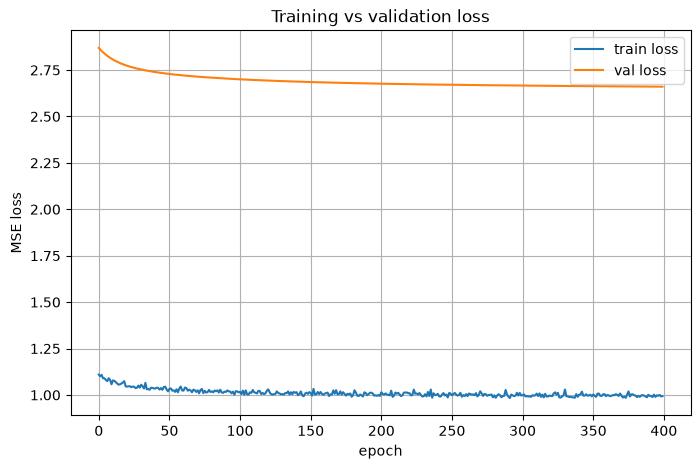

In [447]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_i, label='train loss')
plt.plot(val_loss_i, label='val loss')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('Training vs validation loss')
plt.legend()
plt.grid()
plt.show()

## Conclusion

The key thing to recognize here is that this result is actually expected and correct—predicting raw asset prices with a single scalar feature to beat a naive persistence baseline is notoriously difficult for efficiently-traded assets like gold. This aligns with financial theory around market efficiency and the random walk hypothesis; even sophisticated models rarely beat the "do-nothing forecaster" on out-of-sample price levels, so the fact that a small **LSTM** built from scratch on limited data doesn't beat it isn't a sign of implementation failure.

A 4-hidden-unit LSTM on 1500 univariate points isn't underpowered for this task; the task itself has almost no learnable signal in it at that scale. Your val loss being worse than train (0.99 vs 2.66) plus failing the naive baseline is consistent with the model latching onto train-period noise that doesn't generalize — which is exactly what you'd expect when the true signal-to-noise ratio is near zero.